# 14 - A Natural Experiment That Does Not Hold: the 2019 Durres Earthquake

Every result so far is *associational*. This notebook tests whether the one plausible **causal** design in reach - the 26 November 2019 M6.4 Durres earthquake as a natural experiment - can upgrade a slice of the paper. PISA's sampling `STRATUM` encodes a North / Center / South band; quake damage concentrated in the **Center** band (Durres + Tirana). A difference-in-differences compares the change in the at-risk rate in Center (treated) vs North+South (control) from pre-quake **2018** to post-quake **2022**.

The honest result: **the design fails its own diagnostics.** The naive DiD looks significant, but the pre-quake placebo rejects parallel trends, the urbanicity triple-difference is ~0, and the effect is null under school-clustered inference. We therefore report a *well-identified null* - the 2022 collapse is national, not a localised shock - which strengthens the paper's structural-crisis reading. Results are pre-computed by `scripts/run_causal_did.py` (design-based BRR + Rubin SEs).

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
import json
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
es = pd.read_csv('../outputs/results/causal_event_study_2015_2022.csv')
summ = json.load(open('../outputs/results/causal_did_summary.json'))
lookup = pd.read_csv('../outputs/results/stratum_region_lookup.csv')

## 0. Region encoding from the sampling stratum

Albania has no subnational `REGION` in the public file, but the explicit sampling stratum labels every school `<Urbanicity> / <Region band> / <Sector>`. The band is stable across 2015/2018/2022 even though the numeric codes change; we parse the label text. Center = quake-affected treated group.

In [3]:
lookup[lookup.region.notna()][['CYCLE','STRATUM','region','urbanicity','sector']].sort_values(['CYCLE','region']).head(12)

,CYCLE,STRATUM,region,urbanicity,sector
0,2015,ALB0010,Center,Rural,Private
5,2015,ALB0003,Center,Urban,Public
6,2015,ALB0004,Center,Urban,Private
12,2015,ALB0009,Center,Rural,Public
1,2015,ALB0001,North,Urban,Public
3,2015,ALB0002,North,Urban,Private
9,2015,ALB0007,North,Rural,Public
11,2015,ALB0008,North,Rural,Private
2,2015,ALB0011,South,Rural,Public
4,2015,ALB0012,South,Rural,Private


## 1. Event study: at-risk rate by region band

The parallel-trends assumption is visual here: do the bands move together *before* the quake (2015 to 2018)? Bars are design-based 95% CIs (BRR + plausible values).

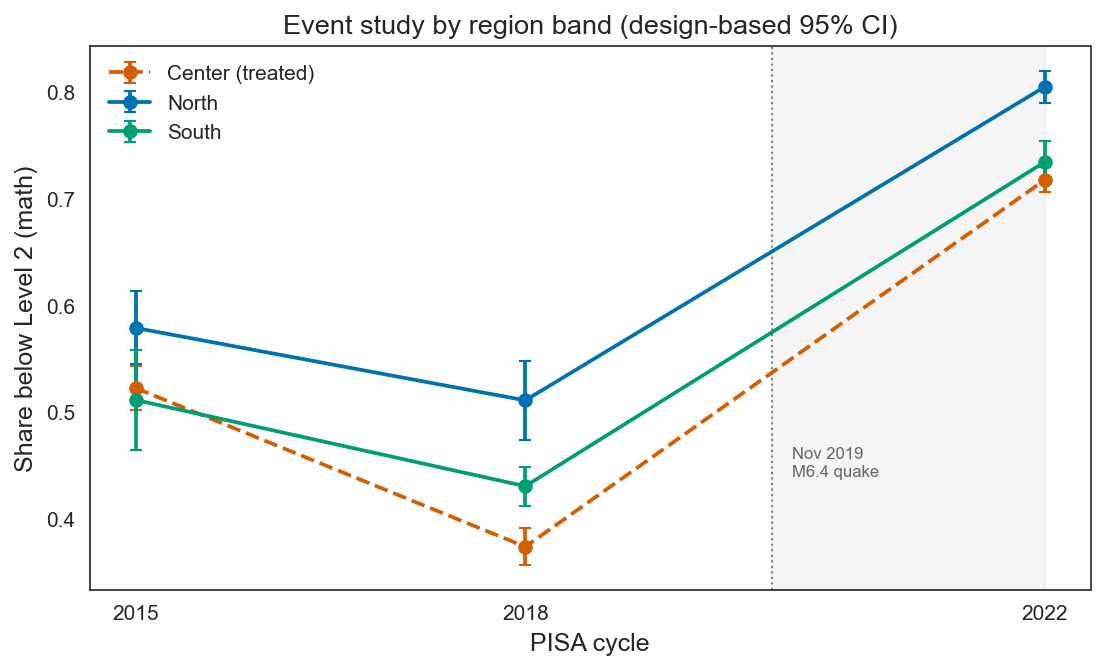

,CYCLE,region,treated,at_risk,se,ci95_low,ci95_high,n
0,2015,North,False,0.579,0.017,0.545,0.613,1264
1,2015,Center,True,0.523,0.011,0.502,0.544,2919
2,2015,South,False,0.511,0.024,0.465,0.558,1032
3,2018,North,False,0.511,0.019,0.474,0.548,1483
4,2018,Center,True,0.374,0.009,0.356,0.391,3018
5,2018,South,False,0.431,0.009,0.412,0.449,1858
6,2022,North,False,0.805,0.008,0.790,0.820,1208
7,2022,Center,True,0.718,0.006,0.706,0.730,3139
8,2022,South,False,0.735,0.010,0.716,0.754,1782


In [4]:
fig, ax = plt.subplots(figsize=(7.5,4.6))
cmap = {'Center':PALETTE['vermilion'],'North':PALETTE['blue'],'South':PALETTE['green']}
for band, s in es.groupby('region'):
    s = s.sort_values('CYCLE')
    lbl = band + (' (treated)' if band=='Center' else '')
    ax.errorbar(s.CYCLE, s.at_risk, yerr=1.96*s.se, marker='o', capsize=3,
                color=cmap[band], label=lbl, ls='--' if band=='Center' else '-')
ax.axvspan(2019.9, 2022, color='0.5', alpha=0.08)
ax.axvline(2019.9, color='0.5', ls=':', lw=1)
ax.text(2020.05, 0.44, 'Nov 2019\nM6.4 quake', fontsize=8, color='0.4')
ax.set_xticks([2015,2018,2022]); ax.set_xlabel('PISA cycle')
ax.set_ylabel('Share below Level 2 (math)')
ax.set_title('Event study by region band (design-based 95% CI)')
ax.legend(frameon=False); plt.tight_layout(); plt.show()
es.round(3)

**Reading:** the bands do **not** move in parallel before the quake. From 2015 to 2018 the Center band improved faster (fell ~15 pp) than North (~7 pp) or South (~8 pp) - it was already on a steeper trajectory. Then from 2018 to 2022 *every* band explodes upward by ~30-40 pp. The pre-quake divergence is the first warning that a DiD here will not cleanly isolate the earthquake.

## 2. Difference-in-differences and its placebo

$\text{DiD} = (Y^{\text{Center}}_{\text{post}}-Y^{\text{Center}}_{\text{pre}}) - (Y^{\text{Control}}_{\text{post}}-Y^{\text{Control}}_{\text{pre}})$. The placebo runs the identical estimator on the pre-quake window 2015 to 2018, where the true effect is zero by construction - a non-zero placebo means parallel trends is violated.

In [5]:
d, pl = summ['did_main_2018_2022'], summ['did_placebo_2015_2018']
tab = pd.DataFrame({
  'window':['main 2018->2022','placebo 2015->2018'],
  'treated_change':[d['treated_change'], pl['treated_change']],
  'control_change':[d['control_change'], pl['control_change']],
  'DiD':[d['did'], pl['did']], 'se':[d['se'], pl['se']],
  '95%CI':[f"[{d['ci95_low']:.3f}, {d['ci95_high']:.3f}]",
           f"[{pl['ci95_low']:.3f}, {pl['ci95_high']:.3f}]"],
  'p':[d['p_value'], pl['p_value']]})
tab.round(4)

,window,treated_change,control_change,DiD,se,95%CI,p
0,main 2018->2022,0.3441,0.2967,0.0475,0.0137,"[0.021, 0.074]",0.0005
1,placebo 2015->2018,-0.1489,-0.0791,-0.0698,0.0199,"[-0.109, -0.031]",0.0005


**Reading:** the naive DiD is **+4.7 pp** (p < 0.001, design-based) - superficially a localised quake effect. But the **placebo is -7.0 pp (p < 0.001)**: in the pre-quake window the Center band was already diverging from control by *more* than the main estimate, in the opposite direction. Parallel trends is decisively rejected, so the main DiD is not a credible causal estimate - it is mostly the continuation of a pre-existing capital-region trend.

## 3. Triple-difference: netting out the capital-region trend

The quake damage was concentrated in the **urban** cores of the Center band (Durres and Tirana cities). A real quake effect should widen the urban-minus-rural at-risk gap in Center more than in control. Differencing on urbanicity removes any Center-wide secular trend - the confound that broke the placebo.

In [6]:
ddd, dpl = summ['ddd_main_2018_2022'], summ['ddd_placebo_2015_2018']
reg = summ['did_regression_clustered_2018_2022']
pd.DataFrame({
  'estimate':['DDD main 2018->2022','DDD placebo 2015->2018','DiD school-clustered'],
  'value':[ddd['ddd'], dpl['ddd'], reg['did']],
  'se':[ddd['se'], dpl['se'], reg['se']],
  'p':[ddd['p_value'], dpl['p_value'], reg['p_value']]}).round(4)

,estimate,value,se,p
0,DDD main 2018->2022,-0.0334,0.0372,0.3703
1,DDD placebo 2015->2018,-0.0481,0.0422,0.2548
2,DiD school-clustered,0.0518,0.0426,0.2246


**Reading:** the triple-difference is **~-3 pp and not significant (p ~ 0.37)** - and the wrong sign for a quake story (urban Center did not worsen *more* than its rural counterpart). Once the capital-wide trend is differenced out, the apparent effect disappears. The school-clustered regression agrees: **+5 pp but p ~ 0.22**, null. The tight design-based SE on the naive DiD was an artefact of ignoring school-level clustering and the pre-trend.

## Conclusions & Interpretation

- **The natural experiment does not identify a causal earthquake effect.** A plausible DiD is rejected by its own placebo (parallel trends fail), collapses under an urbanicity triple-difference, and is null under school-clustered inference.
- **The 2022 collapse is national, not localised.** At-risk jumps ~30-40 pp in *every* band and urbanicity cell - consistent with a country-wide COVID-plus-sample-coverage shock, not a Durres-region disaster signal.
- **Why report a null?** It is the honest, well-identified answer, and it forecloses the natural over-claim that the earthquake caused the crisis. It reinforces the paper's thesis that the 2022 crisis is structural and national.
- **Data ceiling.** The public file cannot separate Durres (epicentre) from Tirana, and only two pre-periods (2015, 2018) carry a decodable band - so no estimator can rescue identification here. Reported for transparency, not buried.